<a href="https://colab.research.google.com/github/sergekamanzi/AirQuality-Forecasting/blob/main/Air_Quality_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


Load and Explore Data

In [2]:
# Load the datasets
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Data Exploration
print("Training Data Overview:")
print(train.head())
print("\nColumn Names:")
print(train.columns)
print("\nMissing Values in Train:")
print(train.isnull().sum())
print("\nMissing Values in Test:")
print(test.isnull().sum())
print("\nTraining Data Summary:")
print(train.describe())


Training Data Overview:
   No      DEWP      TEMP      PRES       Iws        Is        Ir  \
0   1 -1.580878 -1.922250  0.443328 -0.441894 -0.069353 -0.137667   
1   2 -1.580878 -2.004228  0.345943 -0.379306 -0.069353 -0.137667   
2   3 -1.580878 -1.922250  0.248559 -0.343514 -0.069353 -0.137667   
3   4 -1.580878 -2.168183  0.248559 -0.280926 -0.069353 -0.137667   
4   5 -1.511594 -2.004228  0.151174 -0.218339 -0.069353 -0.137667   

              datetime   cbwd_NW   cbwd_SE   cbwd_cv  pm2.5  
0  2010-01-01 00:00:00  1.448138 -0.732019 -0.522096    NaN  
1  2010-01-01 01:00:00  1.448138 -0.732019 -0.522096    NaN  
2  2010-01-01 02:00:00  1.448138 -0.732019 -0.522096    NaN  
3  2010-01-01 03:00:00  1.448138 -0.732019 -0.522096    NaN  
4  2010-01-01 04:00:00  1.448138 -0.732019 -0.522096    NaN  

Column Names:
Index(['No', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'datetime', 'cbwd_NW',
       'cbwd_SE', 'cbwd_cv', 'pm2.5'],
      dtype='object')

Missing Values in Train:
No      

Datetime Handling and Missing Value Treatment

In [3]:
# Convert 'datetime' to datetime format
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Set 'datetime' as index
train.set_index('datetime', inplace=True)
test.set_index('datetime', inplace=True)

# Interpolate missing values
train['pm2.5'] = train['pm2.5'].interpolate(method='time')
test = test.interpolate(method='time')

# Fill any remaining missing values with mean
train.fillna(train.mean(), inplace=True)
test.fillna(test.mean(), inplace=True)


Feature Engineering & Selection

In [4]:
# Add time-based features
train['hour'] = train.index.hour
train['day'] = train.index.day
train['month'] = train.index.month
test['hour'] = test.index.hour
test['day'] = test.index.day
test['month'] = test.index.month

# Drop identifier column and separate features and target
X_train = train.drop(['pm2.5', 'No'], axis=1)
y_train = train['pm2.5']
X_test = test.drop(['No'], axis=1)

# Select top 6 features
selector = SelectKBest(score_func=f_regression, k=6)
selector.fit(X_train, y_train)
selected_features = X_train.columns[selector.get_support()]
print("\nSelected Features:", selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]



Selected Features: Index(['DEWP', 'PRES', 'Iws', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv'], dtype='object')


Feature Scaling and Sequence Creation

In [5]:
# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create sequences for LSTM
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(target[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 24  # 24-hour sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)

# Prepare test data sequences with padding
X_test_seq = []
for i in range(len(X_test_scaled)):
    start_idx = max(0, i - seq_length + 1)
    sequence = X_test_scaled[start_idx:i + 1]
    if len(sequence) < seq_length:
        padding = np.repeat(sequence[0:1], seq_length - len(sequence), axis=0)
        sequence = np.vstack((padding, sequence))
    X_test_seq.append(sequence)
X_test_seq = np.array(X_test_seq)


Define & Compile LSTM Model

In [6]:
# Define LSTM Model
model = Sequential([
    Bidirectional(LSTM(256, activation='tanh', return_sequences=True,
                       kernel_regularizer=regularizers.l2(0.005)),
                  input_shape=(seq_length, X_train.shape[1])),
    Dropout(0.5),
    LSTM(128, activation='tanh', kernel_regularizer=regularizers.l2(0.005)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8)
model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Show model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 512)        │       538,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875,137 (3.34 MB)

 Trainable params: 875,137 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

Train Model with Callbacks

In [7]:
# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Epoch 1/50
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 257s 162ms/step - loss: 8696.8389 - root_mean_squared_error: 92.9228 - val_loss: 10488.2275 - val_root_mean_squared_error: 102.3796 - learning_rate: 0.0010
Epoch 2/50
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 261s 162ms/step - loss: 6565.4609 - root_mean_squared_error: 80.9732 - val_loss: 9995.0420 - val_root_mean_squared_error: 99.9319 - learning_rate: 0.0010
Epoch 3/50
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 249s 162ms/step - loss: 5964.6733 - root_mean_squared_error: 77.1601 - val_loss: 9168.1445 - val_root_mean_squared_error: 95.6923 - learning_rate: 0.0010
Epoch 4/50
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 256s 158ms/step - loss: 5616.8394 - root_mean_squared_error: 74.8577 - val_loss: 8547.5791 - val_root_mean_squared_error: 92.3828 - learning_rate: 0.0010
Epoch 5/50
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 251s 164ms/step - loss: 5530.6675 - root_mean_squared_error: 74.2712 - val_loss: 8203.8174 - val_root_mean_squared_error: 90.4938 - learning_rate: 0.0010
Epoch 6/50
1533/15

Visualize Training Results

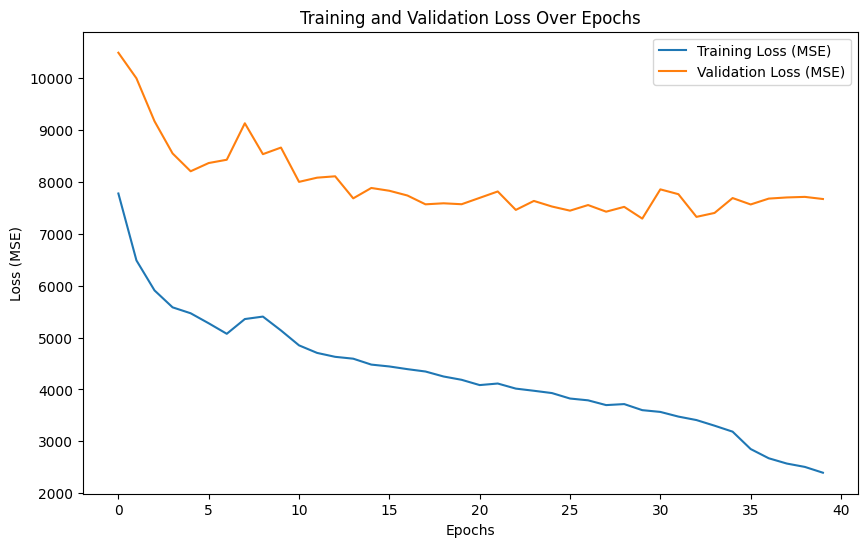

In [8]:
# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


Evaluate and Predict

In [9]:
# Final training RMSE
train_predictions = model.predict(X_train_seq)
train_rmse = np.sqrt(np.mean((y_train_seq - train_predictions.flatten())**2))
print(f"Final Training RMSE: {train_rmse}")

# Predict on test data
predictions = model.predict(X_test_seq)
predictions = np.nan_to_num(predictions, nan=0.0)
predictions = np.maximum(predictions, 0)  # No negative predictions


958/958 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step
Final Training RMSE: 65.73460890405607
411/411 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step


 Save Submission File

In [10]:
# Prepare submission DataFrame
submission = pd.DataFrame({
    'row ID': pd.to_datetime(test.index).strftime('%Y-%m-%d %-H:%M:%S'),
    'pm2.5': predictions.flatten()
})
submission = submission.sort_values(by='row ID')

# Save to CSV
output_path = '/content/submission.csv'
submission.to_csv(output_path, index=False)
print(f"Submission file saved as '{output_path}'")


Submission file saved as '/content/submission.csv'
